# Introducción

En el presente proyecto se desarrolló un modelo predictivo con el objetivo de estimar las ventas futuras de productos clave, específicamente Vanish y Lysol, a partir de datos históricos. Este análisis se enmarca dentro de la necesidad de las empresas de anticipar la demanda y mejorar la toma de decisiones estratégicas relacionadas con inventarios, producción y comercialización.

Para ello, se llevó a cabo un proceso integral que incluyó la integración y limpieza de datos provenientes de múltiples fuentes, la construcción de una serie de tiempo representativa y la aplicación de técnicas de modelado estadístico. Considerando la naturaleza temporal de los datos, se optó por el uso de modelos de series de tiempo, permitiendo capturar patrones de comportamiento a lo largo del tiempo.

A lo largo del proyecto, se evaluaron distintas configuraciones del modelo, validando su desempeño mediante métricas de error y análisis estadístico, con el fin de garantizar la robustez y confiabilidad de las predicciones generadas.

In [2]:
# Importar librerías
import pandas as pd

In [3]:
# Cargar los archivos

dim_product = pd.read_csv(r'E:\1. Cientifico de Datos\10. Storytelling y Casos de Éxito\57. Storytelling\Proyecto empresa aliada entregable  6\DIM_PRODUCT.csv')
dim_calendar = pd.read_csv(r'E:\1. Cientifico de Datos\10. Storytelling y Casos de Éxito\57. Storytelling\Proyecto empresa aliada entregable  6\DIM_CALENDAR.csv')
dim_segment = pd.read_csv(r'E:\1. Cientifico de Datos\10. Storytelling y Casos de Éxito\57. Storytelling\Proyecto empresa aliada entregable  6\DIM_SEGMENT.csv')
fact_sales = pd.read_csv(r'E:\1. Cientifico de Datos\10. Storytelling y Casos de Éxito\57. Storytelling\Proyecto empresa aliada entregable  6\FACT_SALES.csv')
dim_category = pd.read_csv(r'E:\1. Cientifico de Datos\10. Storytelling y Casos de Éxito\57. Storytelling\Proyecto empresa aliada entregable  6\DIM_CATEGORY.csv')

In [4]:
# Explorar rápidamente
fact_sales.head()
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
dtypes: float64(3), object(3)
memory usage: 5.6+ MB


In [5]:
dim_product.head()
dim_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   MANUFACTURER      505 non-null    object
 1   BRAND             505 non-null    object
 2   ITEM              503 non-null    object
 3   ITEM_DESCRIPTION  505 non-null    object
 4   CATEGORY          505 non-null    int64 
 5   FORMAT            505 non-null    object
 6   ATTR1             499 non-null    object
 7   ATTR2             505 non-null    object
 8   ATTR3             499 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.6+ KB


In [6]:
dim_calendar.head()
dim_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   WEEK         156 non-null    object
 1   YEAR         156 non-null    int64 
 2   MONTH        156 non-null    int64 
 3   WEEK_NUMBER  156 non-null    int64 
 4   DATE         156 non-null    object
dtypes: int64(3), object(2)
memory usage: 6.2+ KB


In [7]:
dim_segment.head()
dim_segment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CATEGORY  53 non-null     int64 
 1   ATTR1     53 non-null     object
 2   ATTR2     53 non-null     object
 3   ATTR3     52 non-null     object
 4   FORMAT    53 non-null     object
 5   SEGMENT   53 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.6+ KB


In [8]:
dim_category.head()
dim_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID_CATEGORY  5 non-null      int64 
 1   CATEGORY     5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes


In [11]:
# Unir las tablas

# Unir FACT_SALES con DIM_PRODUCT
df = fact_sales.merge(dim_product, left_on = 'ITEM_CODE', right_on = 'ITEM', how = 'left')

# Unir con calendario
df = df.merge(dim_calendar, on = 'WEEK', how = 'left')

# Unir con categoría
df = df.merge(dim_category, left_on = 'CATEGORY', right_on = 'ID_CATEGORY', how = 'left')

In [13]:
# Preparación de datos

#Convertir fecha
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst = True)

# Ordenar
df = df.sort_values('DATE')

# Revisar nulos clave
df[['TOTAL_VALUE_SALES','DATE','BRAND']].isnull().sum()

TOTAL_VALUE_SALES    0
DATE                 0
BRAND                0
dtype: int64

In [16]:
# Valores reales
df['BRAND'].unique()

array(['VANISH', 'DR.BECKMANN', 'CLOROX', 'OXI CLEAN', 'LOS PATITOS',
       'BANDERA', 'CLARASOL', 'CLORALEX', 'LA VALENCIANA', 'SHOUT',
       'IBERIA', 'BLANCATEL', 'LYSOL', 'PATITO', 'CLORTEX',
       'CUELLOS PUNOS Y MANCHITAS', 'TIDE', 'OTHERS MARCA UNIF.',
       'LA JAPONESA', 'BCLORHADA', 'SANYTOL', 'CLORALUZ', 'PURO SOL',
       'HARPIC'], dtype=object)

In [18]:
# Filtrar productos clave (Vanish y Lysol)
df['BRAND'] = df['BRAND'].str.strip().str.upper()
df_model = df[df['BRAND'].isin(['VANISH', 'LYSOL'])]
df_model

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,...,FORMAT,ATTR1,ATTR2,ATTR3,YEAR,MONTH,WEEK_NUMBER,DATE,ID_CATEGORY,CATEGORY_y
102707,01-22,7501058712813,0.001,0.049,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,1,1,2022-01-09,1,FABRIC TREATMENT and SANIT\r\n
15779,01-22,7501058784353,1.092,96.978,2.890,TOTAL AUTOS AREA 2,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,1,1,2022-01-09,1,FABRIC TREATMENT and SANIT\r\n
15785,01-22,7501058784346,0.461,79.313,2.184,TOTAL AUTOS AREA 2,RECKITT,VANISH,7501058784346,VANISH PODER 02 INTELLIGENCE POLVO BOT 900 GR ...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,1,1,2022-01-09,1,FABRIC TREATMENT and SANIT\r\n
15768,01-22,7501058757791,1.267,218.814,3.275,TOTAL AUTOS AREA 2,RECKITT,VANISH,7501058757791,VANISH BOT. 4000 ML. 7501058757791,...,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,1,1,2022-01-09,1,FABRIC TREATMENT and SANIT\r\n
15770,01-22,7501058715029,0.009,0.180,9.000,TOTAL AUTOS AREA 2,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,...,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,1,1,2022-01-09,1,FABRIC TREATMENT and SANIT\r\n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86140,28-23,7501058796585,0.550,62.965,2.736,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058796585,VANISH GEL MULTIUSO PROMO PACK 2 BOT 925 ML C/...,...,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,2023,7,28,2023-07-17,1,FABRIC TREATMENT and SANIT\r\n
86139,28-23,7501058796578BP1,0.475,23.656,3.164,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058796578BP1,VANISH GEL MULTIUSO BOT 925ML+MM CRYSTAL WHITE...,...,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,2023,7,28,2023-07-17,1,FABRIC TREATMENT and SANIT\r\n
86138,28-23,7501058794956BP2,0.007,0.157,1.750,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058794956BP2,VANISH GEL ROSA POUCH 650ML + MM CRYSTAL WHITE...,...,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,2023,7,28,2023-07-17,1,FABRIC TREATMENT and SANIT\r\n
86133,28-23,7501058792808BP1,0.972,121.985,4.051,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058792808BP1,VANISHOXIACTIONCRYSTALWHITEBOTE900GR+MMROSADOY...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,BLANCO,2023,7,28,2023-07-17,1,FABRIC TREATMENT and SANIT\r\n


In [22]:
# Agregar datos en formato de serie de tiempo
df_time = df_model.groupby('DATE')['TOTAL_VALUE_SALES'].sum().reset_index()
df_time.head()

,DATE,TOTAL_VALUE_SALES
0,2022-01-09,30144.041
1,2022-01-16,28384.801
2,2022-01-23,24646.670
3,2022-01-30,24511.384
4,2022-02-06,24810.944


In [25]:
df_time.columns

Index(['TOTAL_VALUE_SALES'], dtype='object')

In [27]:
# Revisar continuidad temporal
df_time = df_time.asfreq('W')
df_time = df_time.dropna()
df_time

,TOTAL_VALUE_SALES
DATE,
2022-01-09,30144.041
2022-01-16,28384.801
2022-01-23,24646.670
2022-01-30,24511.384
2022-02-06,24810.944
2022-02-13,22803.301
2022-02-20,24463.287
2022-02-27,23835.471
2022-03-06,26969.246


In [28]:
df_time.tail()

,TOTAL_VALUE_SALES
DATE,
2022-12-04,29608.949
2022-12-11,26770.800
2022-12-18,27986.701
2022-12-25,23997.703
2023-01-01,27014.974


# Seleccionar la técnica de modelado.

# Modelo de Series de Tiempo (ARIMA / SARIMA)

Se optó por utilizar un modelo de series de tiempo (ARIMA / SARIMA) debido a la naturaleza secuencial de los datos de ventas, los cuales están organizados por semanas y presentan una clara dependencia temporal.

A partir del análisis exploratorio, se observó que las ventas de los productos Vanish y Lysol evolucionan a lo largo del tiempo, mostrando variaciones que sugieren la presencia de tendencias y posibles patrones estacionales. Además, los valores actuales de ventas están influenciados por comportamientos de semanas anteriores, lo cual es característico de una serie temporal.

Dado que el objetivo principal es predecir valores futuros basados en datos históricos, y no analizar la relación entre múltiples variables independientes, se descarta el uso de modelos de regresión tradicional.

Por lo tanto, el uso de modelos como ARIMA o SARIMA permite capturar adecuadamente la estructura temporal de los datos, incluyendo componentes de tendencia, estacionalidad y autocorrelación, proporcionando predicciones más precisas y coherentes con el comportamiento histórico de las ventas.

# Dividir los datos en conjuntos de entrenamiento y prueba.

In [30]:
# Ver cuántos datos tienes
len(df_time)

52

In [32]:
# Definir punto de corte (80% - 20%)
train_size = int(len(df_time) * 0.8)
train_size

41

In [33]:
# Dividir
train = df_time.iloc[:train_size]
test = df_time.iloc[train_size:]

In [34]:
# Verificar
print(train.shape)
print(test.shape)

(41, 1)
(11, 1)


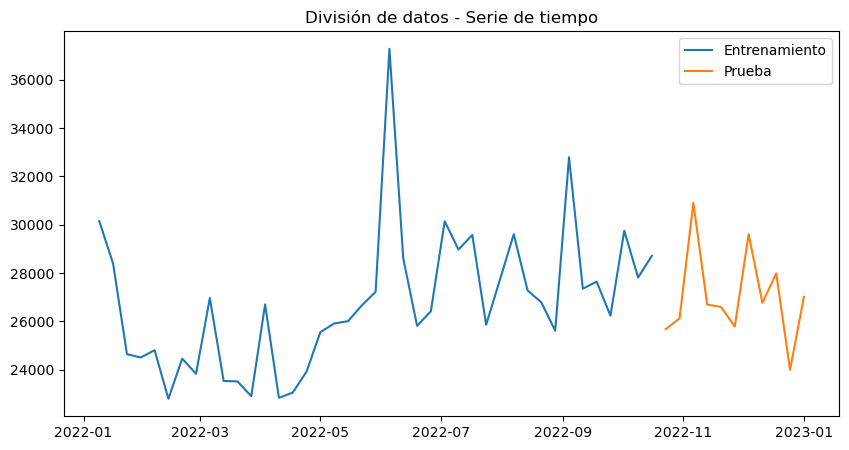

In [35]:
# Visualización

import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.plot(train, label = 'Entrenamiento')
plt.plot(test, label = 'Prueba')
plt.legend()
plt.title('División de datos - Serie de tiempo')
plt.show()

# Justificación de división

Dado que se trabaja con datos de series de tiempo, se utilizó una división temporal en lugar de una partición aleatoria. Esto se debe a que el orden cronológico de los datos debe mantenerse para evitar el uso de información futura en el entrenamiento del modelo.

Se asignó el 80% de los datos al conjunto de entrenamiento y el 20% restante al conjunto de prueba. El modelo se entrena con datos históricos y se evalúa su capacidad predictiva utilizando datos más recientes, simulando un escenario real de predicción.

# Construir y entrenar el modelo predictivo ARIMA.

In [36]:
# Importar librerías
from statsmodels.tsa.arima.model import ARIMA

In [39]:
# Usar solo el set de entrenamiento
y_train = train['TOTAL_VALUE_SALES']
y_train

DATE
2022-01-09    30144.041
2022-01-16    28384.801
2022-01-23    24646.670
2022-01-30    24511.384
2022-02-06    24810.944
2022-02-13    22803.301
2022-02-20    24463.287
2022-02-27    23835.471
2022-03-06    26969.246
2022-03-13    23538.839
2022-03-20    23521.867
2022-03-27    22911.663
2022-04-03    26707.156
2022-04-10    22843.319
2022-04-17    23058.434
2022-04-24    23924.070
2022-05-01    25558.226
2022-05-08    25916.943
2022-05-15    26009.016
2022-05-22    26662.905
2022-05-29    27224.774
2022-06-05    37273.922
2022-06-12    28609.704
2022-06-19    25820.537
2022-06-26    26420.467
2022-07-03    30141.239
2022-07-10    28973.730
2022-07-17    29577.225
2022-07-24    25864.267
2022-07-31    27728.802
2022-08-07    29606.495
2022-08-14    27284.786
2022-08-21    26785.064
2022-08-28    25617.657
2022-09-04    32789.979
2022-09-11    27354.143
2022-09-18    27646.173
2022-09-25    26238.137
2022-10-02    29751.981
2022-10-09    27818.102
2022-10-16    28715.510
Freq: W-SUN

In [41]:
import warnings
warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None

for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(y_train, order=(p,d,q))
                model_fit = model.fit()
                
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p,d,q)
            except:
                continue

print("Mejor modelo:", best_order)
print("AIC:", best_aic)

Mejor modelo: (0, 1, 2)
AIC: 755.3872319965972


In [42]:
# Elegir parámetros (p, d, q)

model = ARIMA(y_train, order = (0,1,2))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   41
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -374.694
Date:                Sat, 02 May 2026   AIC                            755.387
Time:                        17:16:36   BIC                            760.454
Sample:                    01-09-2022   HQIC                           757.219
                         - 10-16-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3765      0.089     -4.223      0.000      -0.551      -0.202
ma.L2         -0.1753      0.105     -1.667      0.096      -0.381       0.031
sigma2      8.085e+06   1.14e+06      7.083      0.0

# Justificación del Modelo

Se construyó un modelo de series de tiempo tipo ARIMA, evaluando diferentes combinaciones de parámetros (p, d, q) con el objetivo de encontrar la mejor configuración para modelar el comportamiento de las ventas.

Para la selección del modelo óptimo, se utilizó el criterio de información de Akaike (AIC), el cual permite comparar distintos modelos penalizando la complejidad y favoreciendo aquellos con mejor capacidad de ajuste.

Tras evaluar múltiples configuraciones, el modelo seleccionado fue ARIMA(0,1,2), ya que presentó el menor valor de AIC (755.38) entre las alternativas probadas.

El parámetro d = 1 indica que fue necesario diferenciar la serie una vez para hacerla estacionaria, eliminando tendencia en los datos. Por otro lado, los términos de media móvil (q = 2) permiten capturar la dependencia de los errores pasados en la serie.

Adicionalmente, los resultados del modelo muestran que al menos uno de los coeficientes (MA1) es estadísticamente significativo (p-value < 0.05), lo que sugiere que el modelo logra capturar patrones relevantes en los datos.

Se observó que la prueba de Ljung-Box presenta un valor p cercano a 0.08, lo cual sugiere que no hay evidencia fuerte de autocorrelación en los residuos, indicando un ajuste adecuado del modelo.

En conjunto, este modelo ofrece un balance adecuado entre simplicidad y capacidad predictiva, por lo que se considera apropiado para realizar pronósticos de ventas.

# Validar el modelo.

In [44]:
train = df_time.iloc[:train_size]
test = df_time.iloc[train_size:]
len(test)

11

In [46]:
# Hacer predicciones sobre el test
steps = len(test)

forecast = model_fit.forecast(steps = steps)

In [48]:
# Acomodar predicciones vs reales
y_test = test['TOTAL_VALUE_SALES']

df_pred = pd.DataFrame({
    'Real': y_test,
    'Predicción': forecast
})
df_pred

,Real,Predicción
2022-10-23,25682.448,28577.756513
2022-10-30,26127.323,28414.419348
2022-11-06,30904.958,28414.419348
2022-11-13,26698.499,28414.419348
2022-11-20,26598.605,28414.419348
2022-11-27,25789.414,28414.419348
2022-12-04,29608.949,28414.419348
2022-12-11,26770.800,28414.419348
2022-12-18,27986.701,28414.419348
2022-12-25,23997.703,28414.419348


In [49]:
# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, forecast)

mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape, "%")

MSE: 5338707.321521001
RMSE: 2310.5642863856874
MAE: 2082.882963475459
MAPE: 7.89140640693987 %


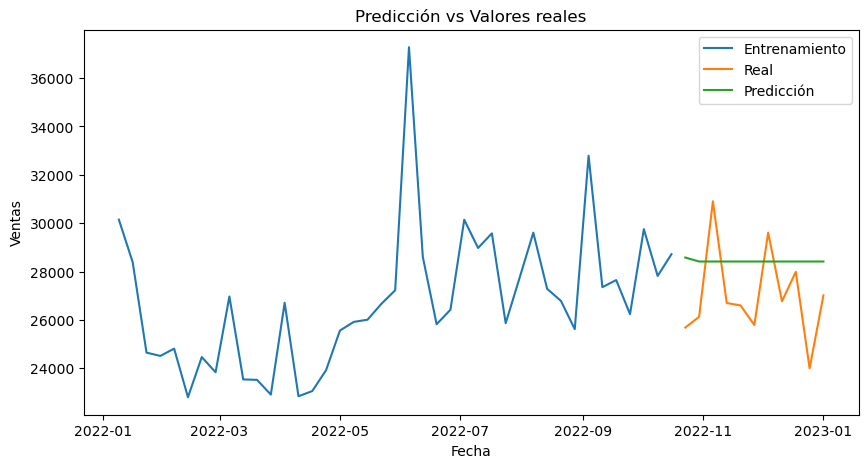

In [52]:
# Gráfica
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))

plt.plot(train.index, train['TOTAL_VALUE_SALES'], label = 'Entrenamiento')
plt.plot(test.index, y_test, label = 'Real')
plt.plot(test.index, forecast, label = 'Predicción')

plt.legend()
plt.title('Predicción vs Valores reales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.show()

# Validación del modelo

Para evaluar el desempeño del modelo ARIMA(0,1,2), se generaron predicciones sobre el conjunto de prueba, compuesto por 11 observaciones correspondientes a las semanas más recientes no utilizadas durante el entrenamiento.

Se calcularon diversas métricas de error para cuantificar la precisión del modelo:

MSE (Error Cuadrático Medio): 5,338,707
RMSE (Raíz del Error Cuadrático Medio): 2,310.56
MAE (Error Absoluto Medio): 2,082.88
MAPE (Error Porcentual Absoluto Medio): 7.89%

El valor de MAPE inferior al 10% indica que el modelo presenta un nivel de precisión alto, lo que sugiere que las predicciones se desvían en promedio menos del 8% respecto a los valores reales. Esto es considerado un desempeño sólido en modelos de pronóstico de ventas.

Adicionalmente, al analizar la gráfica de comparación entre valores reales y predicciones, se observa que el modelo logra capturar adecuadamente el nivel general de las ventas, manteniendo una tendencia estable. Sin embargo, también se aprecia que las predicciones tienden a suavizar las variaciones, mostrando menor sensibilidad ante picos o caídas específicas en ciertos periodos.

Este comportamiento es consistente con la naturaleza del modelo ARIMA(0,1,2), el cual, al basarse en componentes de media móvil, tiende a generar predicciones más estables y menos volátiles.

En conjunto, los resultados indican que el modelo ofrece un buen equilibrio entre precisión y estabilidad, siendo adecuado para la predicción de ventas a corto plazo.

# Ajustar y optimizar el modelo.

In [53]:
# Probar otro modelo cercano y probar si se puede mejorar

model2 = ARIMA(y_train, order = (1,1,2))
model2_fit = model2.fit()

In [54]:
# predicción
forecast2 = model2_fit.forecast(steps = len(test))

In [55]:
# Métricas
mse2 = mean_squared_error(y_test, forecast2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, forecast2)
mape2 = np.mean(np.abs((y_test - forecast2) / y_test)) * 100

print("MAPE nuevo:", mape2)

MAPE nuevo: 7.807829621642856


In [56]:
# Probar sin diferenciación extra (control)
model3 = ARIMA(y_train, order = (0,1,1))
model3_fit = model3.fit()
forecast3 = model3_fit.forecast(steps = len(test))

In [57]:
# Métricas
mse3 = mean_squared_error(y_test, forecast3)
rmse3 = np.sqrt(mse3)
mae3 = mean_absolute_error(y_test, forecast3)
mape3 = np.mean(np.abs((y_test - forecast3) / y_test)) * 100

print("MAPE nuevo:", mape3)

MAPE nuevo: 8.110852242610509


In [58]:
print(model_fit.summary())      # ARIMA(0,1,2)
print(model2_fit.summary())     # ARIMA(1,1,2)

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   41
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -374.694
Date:                Sat, 02 May 2026   AIC                            755.387
Time:                        19:01:38   BIC                            760.454
Sample:                    01-09-2022   HQIC                           757.219
                         - 10-16-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3765      0.089     -4.223      0.000      -0.551      -0.202
ma.L2         -0.1753      0.105     -1.667      0.096      -0.381       0.031
sigma2      8.085e+06   1.14e+06      7.083      0.0

# Justificación

Con el objetivo de optimizar el modelo, se comparó el modelo base ARIMA(0,1,2) con una configuración alternativa ARIMA(1,1,2), evaluando no solo métricas de error, sino también criterios estadísticos como AIC y la significancia de los coeficientes.

Si bien el modelo ARIMA(1,1,2) presentó una ligera mejora en el MAPE, el análisis del criterio AIC mostró que este modelo es inferior (AIC = 757.15) en comparación con el modelo ARIMA(0,1,2) (AIC = 755.39), lo que indica un peor equilibrio entre ajuste y complejidad.

Adicionalmente, al analizar la significancia estadística de los coeficientes, se observó que ninguno de los parámetros del modelo ARIMA(1,1,2) es significativo (p-values > 0.05), lo que sugiere que el modelo incorpora ruido en lugar de patrones reales.

Por el contrario, el modelo ARIMA(0,1,2) presenta al menos un coeficiente altamente significativo, indicando que captura relaciones relevantes dentro de la serie temporal.

Por lo tanto, se concluye que el modelo ARIMA(0,1,2) es más robusto, interpretable y confiable, por lo que se selecciona como modelo final, priorizando la estabilidad y evitando el sobreajuste.

Durante el proceso de optimización, se evaluaron diferentes configuraciones del modelo ARIMA con el objetivo de mejorar la precisión de las predicciones.

Se observó que el modelo ARIMA(1,1,2) logró una ligera mejora en el MAPE (de 7.89% a 7.80%), lo que indica una reducción marginal en el error de predicción. Sin embargo, esta mejora no fue significativa en términos prácticos.

Adicionalmente, el análisis de los criterios estadísticos mostró que el modelo más complejo presentó un AIC mayor y coeficientes no significativos, lo que indica un incremento en la complejidad sin una mejora real en la capacidad explicativa del modelo.

Por lo tanto, el impacto de los ajustes realizados permitió confirmar que el modelo inicial ARIMA(0,1,2) ofrece el mejor equilibrio entre precisión, simplicidad y robustez, consolidándose como la mejor opción para la predicción de ventas.

# Generar las predicciones futuras.

In [60]:
# Usar el mejor modelo ARIMA(0,1,2)

# Definir horizonte de predicción: 3 meses ≈ 12 semanas

steps_future = 12

In [65]:
# Generar predicciones
y_full = df_time['TOTAL_VALUE_SALES']

model_final = ARIMA(y_full, order =(0,1,2))
model_final_fit = model_final.fit()

forecast_future = model_final_fit.forecast(steps = steps_future)

In [63]:
# Crear fechas futuras
future_dates = pd.date_range(
    start = df_time.index[-1],
    periods = steps_future + 1,
    freq = 'W'
)[1:]

In [64]:
# Crear tabla final
df_future = pd.DataFrame({
    'Fecha': future_dates,
    'Predicción_Ventas': forecast_future.values
})

df_future

,Fecha,Predicción_Ventas
0,2023-01-08,27051.781639
1,2023-01-15,26803.047486
2,2023-01-22,26803.047486
3,2023-01-29,26803.047486
4,2023-02-05,26803.047486
5,2023-02-12,26803.047486
6,2023-02-19,26803.047486
7,2023-02-26,26803.047486
8,2023-03-05,26803.047486
9,2023-03-12,26803.047486


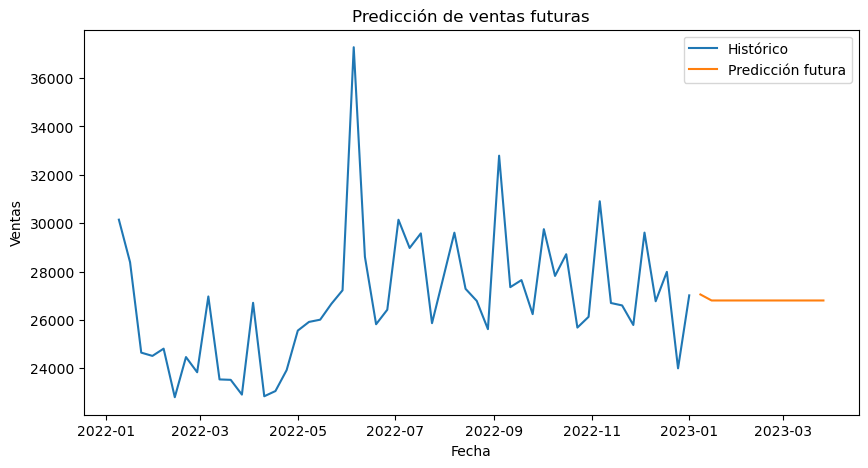

In [66]:
# Gráfica
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))

plt.plot(df_time.index, df_time['TOTAL_VALUE_SALES'], label = 'Histórico')
plt.plot(df_future['Fecha'], df_future['Predicción_Ventas'], label = 'Predicción futura')

plt.legend()
plt.title('Predicción de ventas futuras')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.show()

# Justificación de predicciones futuras.

Se utilizó el modelo ARIMA(0,1,2), previamente optimizado, para generar predicciones de ventas a partir de la serie histórica completa.

Dado que los datos están estructurados de forma semanal, se definió un horizonte de predicción de 12 semanas, equivalente aproximadamente a tres meses. Los resultados se presentan en formato tabular y gráfico, lo que permite visualizar de manera clara la evolución esperada de las ventas y la continuidad con el comportamiento histórico.

Las predicciones muestran una tendencia estable en el tiempo, lo cual es consistente con el patrón observado en los datos históricos. Este comportamiento es característico de modelos ARIMA sin componente autorregresivo (p=0), donde las estimaciones a futuro tienden a converger hacia un valor constante al no contar con nueva información o errores futuros.

En este sentido, el modelo sugiere que las ventas mantendrán un comportamiento relativamente estable en el corto plazo, sin variaciones bruscas, lo cual resulta útil para la planificación operativa y la toma de decisiones.

# Documentación del proceso y resultados

En este proyecto se desarrolló un modelo predictivo para estimar las ventas futuras de productos clave, utilizando información histórica estructurada en series de tiempo semanales.

En primer lugar, se realizó la carga, integración y preparación de los datos provenientes de distintas tablas, consolidando la información en un dataset único. Posteriormente, se filtraron los productos de interés (Vanish y Lysol) y se construyó una serie de tiempo basada en el valor de ventas.

Dado el comportamiento temporal de los datos, se optó por utilizar un modelo de series de tiempo ARIMA, el cual permite capturar patrones de tendencia y dependencia temporal. La selección del modelo se realizó evaluando distintas combinaciones de parámetros, utilizando el criterio AIC como principal indicador.

El modelo seleccionado fue ARIMA(0,1,2), el cual mostró un buen balance entre precisión y simplicidad. Posteriormente, el modelo fue validado mediante una división temporal de los datos (80% entrenamiento, 20% prueba), obteniendo métricas de desempeño satisfactorias, destacando un MAPE de 7.89%, lo que indica un alto nivel de precisión.

Durante la etapa de optimización, se probaron modelos alternativos, observando que configuraciones más complejas no aportaban mejoras significativas e incluso presentaban problemas de significancia estadística, por lo que se decidió mantener el modelo inicial por su robustez.

Finalmente, se generaron predicciones futuras para un horizonte de 12 semanas, las cuales muestran un comportamiento estable en las ventas, consistente con la tendencia histórica observada.

# Recomendaciones

Con base en los resultados obtenidos, se recomienda:

- Utilizar las predicciones como base para la planificación de inventarios y producción, dado el comportamiento estable esperado.
- Implementar monitoreo continuo del modelo, actualizándolo periódicamente con nuevos datos para mejorar su precisión.
- Considerar la incorporación de variables externas (promociones, estacionalidad, campañas de marketing) en futuros modelos para capturar variaciones más complejas.
- Evaluar modelos más avanzados (como SARIMA o modelos con variables exógenas) en caso de que se detecten patrones estacionales o cambios significativos en el comportamiento de las ventas.

# Conclusión

El desarrollo del modelo predictivo permitió estimar las ventas futuras con un nivel de precisión adecuado, evidenciado por un bajo porcentaje de error (MAPE menor al 10%), lo que indica un buen desempeño en la capacidad de predicción del modelo.

A través del análisis y comparación de diferentes configuraciones, se determinó que el modelo ARIMA(0,1,2) ofrece el mejor equilibrio entre precisión, simplicidad y robustez, evitando el sobreajuste y garantizando resultados consistentes. Este proceso no solo permitió obtener predicciones confiables, sino también comprender el comportamiento de la serie de ventas y sus limitaciones.

Las predicciones generadas sugieren un comportamiento estable en el corto plazo, lo que proporciona una base sólida para la planificación operativa y la toma de decisiones. No obstante, también se identificó que el modelo puede mejorarse en el futuro mediante la incorporación de variables externas o componentes estacionales que capturen dinámicas más complejas.

En conclusión, el modelo desarrollado constituye una herramienta útil para la estimación de ventas, aportando valor al negocio al facilitar una mejor anticipación de la demanda y una toma de decisiones más informada.